# Estimating Expression Functions with `smooth_expression`

`kompot.smooth_expression` fits a **Gaussian process over the cell-state
embedding** to turn noisy per-cell counts into a smooth *expression function*
`f(state)` — plus a per-cell **uncertainty** (the GP posterior standard
deviation). It trains on the cells you select and evaluates on **every** cell,
so each cell gets a denoised value and an uncertainty, whether or not it was in
the training set.

This is the **same machinery `kompot.de` uses internally**: differential
expression fits one of these functions per condition and contrasts them. This
tutorial uses the primitive directly, which unlocks three things DE wraps up:
choosing the **length scale**, reading the **uncertainty**, and **training on a
subset then applying elsewhere** (counterfactual expression, modality transfer).

**Dive deeper:**
[Getting Started / DE](./01_getting_started.ipynb) ·
[Advanced DE + `ls_factor`](./02_differential_expression_detailed.ipynb) ·
[Sample variance](./03_sample_variance.ipynb) ·
[Paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769)

In [1]:
%matplotlib inline

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc

import kompot

# Consistent, clean plotting style across the tutorial set
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

## Configuration

Same dataset and cell-state representation as the DE tutorials:

In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
GROUPING_COLUMN = "Age"                 # condition column in adata.obs
CONDITIONS = ["Young", "Old"]           # first entry is the reference
CELL_TYPE_COLUMN = "highres_celltype"   # for visualization only
DIMENSIONALITY_REDUCTION = "DM_EigenVectors"  # cell-state representation
LAYER_FOR_EXPRESSION = "logged_counts"        # expression layer

# A few lineage markers to smooth (myeloid, B, erythroid programs).
GENES = ["Elane", "Mpo", "Cd79a", "Car2"]

from scipy import sparse as _sp
def _dense(x):
    return np.asarray(x.todense()) if _sp.issparse(x) else np.asarray(x)

## Load Data

In [3]:
import os
from pathlib import Path

import requests
from tqdm.auto import tqdm

Path(DATA_PATH).parent.mkdir(parents=True, exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Downloading dataset (~2.4 GB) from Zenodo ...")
    url = "https://zenodo.org/records/15587768/files/murine_bone_marrow_aging.h5ad?download=1"
    response = requests.get(url, stream=True)
    total = int(response.headers.get("content-length", 0))
    with open(DATA_PATH, "wb") as file, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=1 << 20):
            file.write(chunk)
            bar.update(len(chunk))

adata = ad.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'DM_EigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

## Estimate one expression function

Fit the function on the **Young** cells and evaluate it everywhere. Passing
`return_full_results=True` hands back the fitted
[`ExpressionModel`](https://kompot.readthedocs.io/en/latest/api.html) alongside a
summary table; the smoothed values and posterior std are also written to
`adata.layers`.

In [4]:
result = kompot.smooth_expression(
    adata,
    groupby=GROUPING_COLUMN, condition="Young",
    layer=LAYER_FOR_EXPRESSION, obsm_key=DIMENSIONALITY_REDUCTION,
    genes=GENES,
    output=kompot.OutputSettings(return_full_results=True),
)

model = result["model"]                 # the fitted ExpressionModel
sm_key = result["field_names"]["smoothed_key"]   # layer with smoothed values
std_key = result["field_names"]["std_key"]       # layer with posterior std
result["table"]

[2026-07-11 05:21:30,243] [INFO    ] Smoothing condition 'Young': 2,917 cells


Predicting expression:   6%|5         | 1/17 [00:00<?, ?it/s]

Computing GP covariance (diag):   6%|5         | 1/17 [00:00<?, ?it/s]

,mean_smoothed,mean_std
Elane,0.439402,0.097013
Mpo,0.632882,0.097013
Cd79a,0.457794,0.097013
Car2,0.569001,0.097013


The raw counts are noisy; the fitted function denoises them into a smooth
surface over cell state, and the posterior std flags where the estimate is
uncertain — highest where **Young** training cells are sparse (epistemic
uncertainty). Project all three onto the UMAP for one gene:

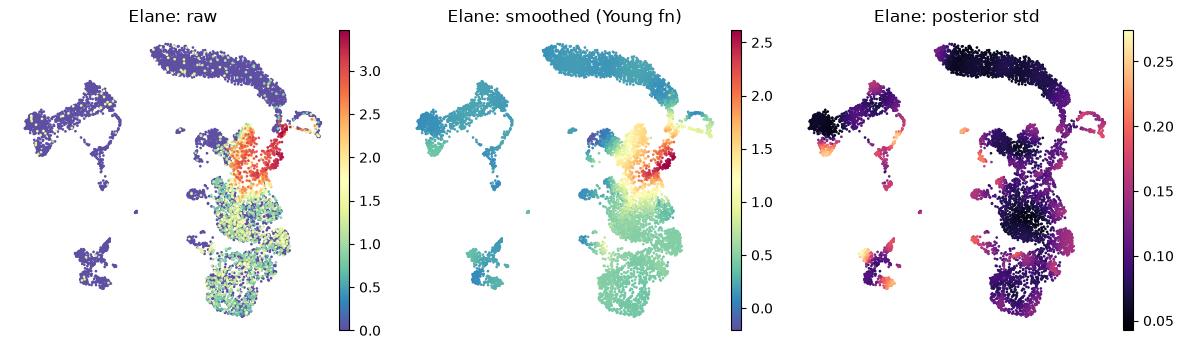

In [5]:
gene = GENES[0]
gi = adata.var_names.get_loc(gene)

adata.obs[f"{gene}: raw"] = _dense(
    adata[:, gene].layers[LAYER_FOR_EXPRESSION]
).ravel()
adata.obs[f"{gene}: smoothed (Young fn)"] = adata.layers[sm_key][:, gi]
adata.obs[f"{gene}: posterior std"] = adata.layers[std_key][:, gi]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
sc.pl.embedding(adata, "umap", color=f"{gene}: raw", ax=axes[0], show=False,
                frameon=False, cmap="Spectral_r")
sc.pl.embedding(adata, "umap", color=f"{gene}: smoothed (Young fn)", ax=axes[1],
                show=False, frameon=False, cmap="Spectral_r")
sc.pl.embedding(adata, "umap", color=f"{gene}: posterior std", ax=axes[2],
                show=False, frameon=False, cmap="magma")
plt.tight_layout()

That is the whole primitive: a denoised expression function **and** a calibrated
uncertainty on the same cell-state geometry. `kompot.de` fits one of these per
condition and scores each gene by the (covariance-aware) distance between them —
see [Getting Started](./01_getting_started.ipynb) and
[Advanced DE](./02_differential_expression_detailed.ipynb).

## Length scales: smoothness ↔ uncertainty ↔ resolution

The **length scale** sets how far the GP pools information across neighboring
cells. `GPSettings(ls_factor=...)` scales the automatically inferred length scale
(default `10`). Fit the same gene at a low, medium, and high `ls_factor` and read
the smoothed value (top) against its posterior std (bottom):

[2026-07-11 05:22:09,948] [INFO    ] Smoothing condition 'Young': 2,917 cells


[2026-07-11 05:22:46,591] [INFO    ] Smoothing condition 'Young': 2,917 cells


[2026-07-11 05:23:24,365] [INFO    ] Smoothing condition 'Young': 2,917 cells


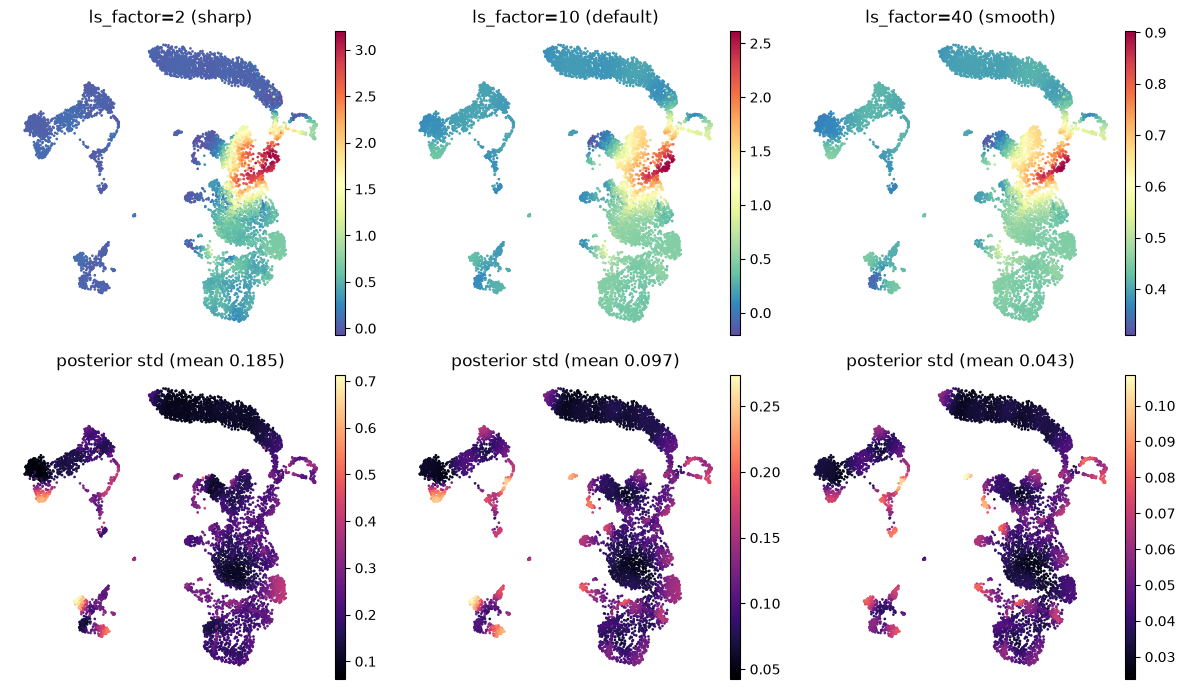

In [6]:
scales = [(2.0, "sharp"), (10.0, "default"), (40.0, "smooth")]
X = adata.obsm[DIMENSIONALITY_REDUCTION]
gj = GENES.index(gene)

fig, axes = plt.subplots(2, len(scales), figsize=(4 * len(scales), 7))
for k, (lsf, tag) in enumerate(scales):
    m = kompot.smooth_expression(
        adata, groupby=GROUPING_COLUMN, condition="Young",
        layer=LAYER_FOR_EXPRESSION, obsm_key=DIMENSIONALITY_REDUCTION, genes=GENES,
        gp=kompot.GPSettings(ls_factor=lsf),
        storage=kompot.StorageSettings(result_key=f"ls_{tag}"),
        output=kompot.OutputSettings(return_full_results=True, inplace=False,
                                     progress=False),
    )["model"]
    smoothed = m.predict(X, progress=False)[:, gj]
    std = m.std(X, progress=False)
    std = std[:, gj] if std.ndim == 2 else std.ravel()
    adata.obs["_sm"] = smoothed
    adata.obs["_st"] = std
    sc.pl.embedding(adata, "umap", color="_sm", ax=axes[0, k], show=False,
                    frameon=False, cmap="Spectral_r",
                    title=f"ls_factor={lsf:g} ({tag})")
    sc.pl.embedding(adata, "umap", color="_st", ax=axes[1, k], show=False,
                    frameon=False, cmap="magma",
                    title=f"posterior std (mean {std.mean():.3f})")
adata.obs.drop(columns=["_sm", "_st"], inplace=True)
plt.tight_layout()

Larger `ls_factor` → a **smoother** surface with **lower** posterior uncertainty,
at the cost of **coarser** spatial resolution (fine structure is averaged away);
smaller `ls_factor` does the reverse. This is the resolution–uncertainty
trade-off. The [Advanced DE tutorial](./02_differential_expression_detailed.ipynb)
covers `ls_factor` in the DE setting and the
[paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769) gives the theory.

## Training on a subset, applying elsewhere

Because the model is *fit* on selected cells but can be *evaluated* at any
coordinates, it doubles as a fit/predict surface:

- `model.predict(X)` / `model.std(X)` evaluate the function (and its
  uncertainty) at **any** embedding coordinates `X`.
- `ModelSettings(model1=model)` re-injects a pre-fitted model into
  `smooth_expression` (or `kompot.de`) on **another** AnnData — no refitting.

Two workflows fall straight out of this.

### Counterfactual expression

Fit the function on a **reference** condition, then evaluate it at *other* cells'
states: the result is *what expression would be if those cells followed the
reference program*. Contrast the Young reference against the Old function — their
difference is exactly the log fold change `kompot.de` reports.

[2026-07-11 05:24:01,842] [INFO    ] Smoothing condition 'Old': 3,116 cells


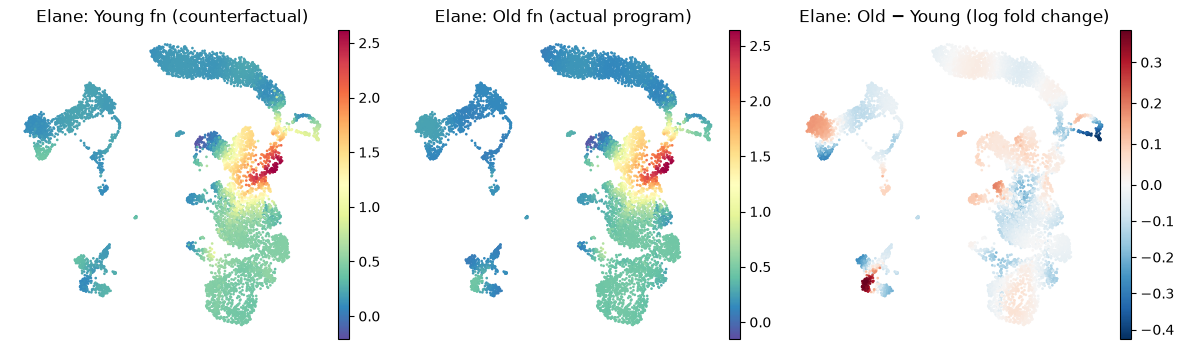

In [7]:
young_fn = model                                  # already fit on Young
old_fn = kompot.smooth_expression(
    adata, groupby=GROUPING_COLUMN, condition="Old",
    layer=LAYER_FOR_EXPRESSION, obsm_key=DIMENSIONALITY_REDUCTION, genes=GENES,
    output=kompot.OutputSettings(return_full_results=True, inplace=False,
                                 progress=False),
)["model"]

gj = GENES.index(gene)
young_pred = young_fn.predict(X, progress=False)[:, gj]   # counterfactual reference
old_pred = old_fn.predict(X, progress=False)[:, gj]
adata.obs[f"{gene}: Young fn (counterfactual)"] = young_pred
adata.obs[f"{gene}: Old fn (actual program)"] = old_pred
adata.obs[f"{gene}: Old − Young (log fold change)"] = old_pred - young_pred

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
sc.pl.embedding(adata, "umap", color=f"{gene}: Young fn (counterfactual)",
                ax=axes[0], show=False, frameon=False, cmap="Spectral_r")
sc.pl.embedding(adata, "umap", color=f"{gene}: Old fn (actual program)",
                ax=axes[1], show=False, frameon=False, cmap="Spectral_r")
sc.pl.embedding(adata, "umap", color=f"{gene}: Old − Young (log fold change)",
                ax=axes[2], show=False, frameon=False, cmap="RdBu_r", vcenter=0)
plt.tight_layout()

### Transferring a modality measured on only some cells

When a measurement exists on only **some** cells (a surface-protein panel, a
spatial readout, a second assay), the same GP can transfer it to the rest. Here we
use the **bare-array** form of the estimator — no AnnData bookkeeping, just
coordinates and values:

- `kompot.ExpressionModel().fit(X, y)` learns the function from cell-state
  coordinates `X` `(n_cells, n_dims)` and values `y` `(n_cells, n_features)`.
- `.predict(X)` / `.std(X)` evaluate the function and its uncertainty at **any**
  coordinates.

This is the estimator that `smooth_expression` and `kompot.de` wrap. To grade the
transfer honestly, we take a real gene and blank it to `NaN` on a **contiguous
patch** of cell states — a region where the modality was never measured — fit on
the cells that keep a value, and impute the blanked patch. A contiguous hole
mirrors the common case (a modality absent from a whole compartment) and lets you
watch the transfer fill it in on the embedding; a classic i.i.d. random hold-out
is equally valid and just needs swapping the mask below. Because we hid real
measurements, we can score the result against the ground truth (a built-in
cross-validation).

In [8]:
gene = GENES[0]
truth = _dense(adata[:, gene].layers[LAYER_FOR_EXPRESSION]).ravel()  # full, pre-masking
X = adata.obsm[DIMENSIONALITY_REDUCTION]

# Blank the modality on a contiguous patch: the cells nearest a reference state.
center = X[np.random.default_rng(0).integers(adata.n_obs)]
dist = np.linalg.norm(X - center, axis=1)
missing = dist <= np.quantile(dist, 0.35)          # ~35% of cells are "unmeasured"
observed = ~missing

feature = truth.copy()
feature[missing] = np.nan                            # the modality, present on ~65% of cells

# Bare-array fit/predict — the estimator underneath smooth_expression.
model = kompot.ExpressionModel()
model.fit(X[observed], feature[observed][:, None])         # train on measured cells only

# Complete the layer: measured cells keep their value, the blanked patch is imputed.
completed = feature.copy()
completed[missing] = model.predict(X[missing], progress=False)[:, 0]

adata.obs[f"{gene}: measured (patch blanked)"] = feature
adata.obs[f"{gene}: completed (imputed)"] = completed
print(f"imputed {int(missing.sum())} cells from {int(observed.sum())} measured cells")

imputed 2832 cells from 5258 measured cells


On the embedding the masked modality shows a **grey hole** where the patch was
blanked; the completed layer fills it in from the shared cell-state geometry:

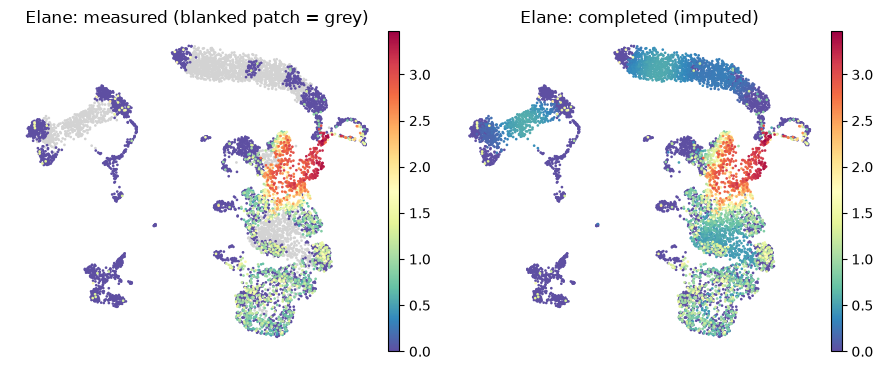

In [9]:
vmin, vmax = np.nanmin(truth), np.nanmax(truth)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
sc.pl.embedding(adata, "umap", color=f"{gene}: measured (patch blanked)", ax=axes[0],
                show=False, frameon=False, cmap="Spectral_r", vmin=vmin, vmax=vmax,
                na_color="lightgrey", title=f"{gene}: measured (blanked patch = grey)")
sc.pl.embedding(adata, "umap", color=f"{gene}: completed (imputed)", ax=axes[1],
                show=False, frameon=False, cmap="Spectral_r", vmin=vmin, vmax=vmax,
                title=f"{gene}: completed (imputed)")
plt.tight_layout()

Because we hid real measurements, we can grade the estimate against ground truth.
Two populations tell two different stories — the **imputed** cells in the blanked
patch (never seen during the fit) and the **smoothed** input cells (denoised
training values) — so we report a separate correlation for each:

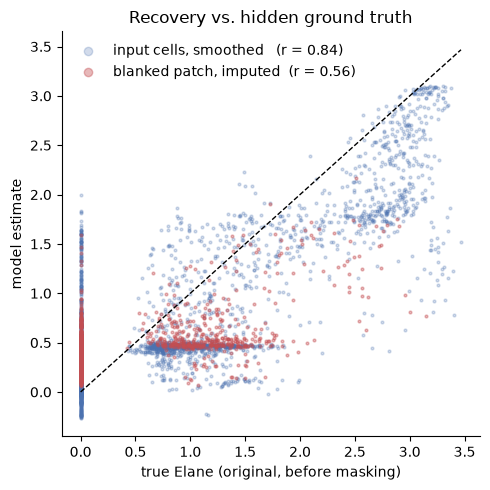

In [10]:
pred_imputed = model.predict(X[missing], progress=False)[:, 0]     # blanked-patch cells
pred_smoothed = model.predict(X[observed], progress=False)[:, 0]   # input cells

r_imputed = np.corrcoef(pred_imputed, truth[missing])[0, 1]
r_smoothed = np.corrcoef(pred_smoothed, truth[observed])[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(truth[observed], pred_smoothed, s=4, alpha=0.25, color="#4C72B0",
           label=f"input cells, smoothed   (r = {r_smoothed:.2f})")
ax.scatter(truth[missing], pred_imputed, s=4, alpha=0.40, color="#C44E52",
           label=f"blanked patch, imputed  (r = {r_imputed:.2f})")
lims = [float(np.nanmin(truth)), float(np.nanmax(truth))]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xlabel=f"true {gene} (original, before masking)",
       ylabel="model estimate", title="Recovery vs. hidden ground truth")
ax.legend(loc="upper left", frameon=False, markerscale=3)
plt.tight_layout()

The gap between the two correlations is the lesson: **smoothed input cells** track
their measured values closely (dense training data), while **imputed cells** in the
blanked patch are harder — the GP carries the modality into states it never saw
there, so accuracy drops and, deep in the patch, estimates regress toward the local
mean. `model.std(X)` flags exactly these low-confidence regions.

The fitted model is reusable without refitting: `ModelSettings(model1=model)`
injects it into `smooth_expression` or `kompot.de` to write imputed values into
another AnnData, or to contrast this function against a second condition.

## Where to go deeper

- **[Getting Started / DE](./01_getting_started.ipynb)** — the front door; `smooth_expression` is the primitive underneath.
- **[Advanced DE + `ls_factor`](./02_differential_expression_detailed.ipynb)** — the length-scale trade-off in the DE setting.
- **[DE with sample variance](./03_sample_variance.ipynb)** — per-gene aleatoric and replicate uncertainty (this tutorial shows the GP/epistemic term).
- **[Differential abundance](./04_differential_abundance.ipynb)** — the same GP geometry applied to cell-state frequency.
- **[Paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769)** ·
  **[Documentation](https://kompot.readthedocs.io)**